# 30.9 Logistic Regression with Imbalanced Data 

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [60]:
from collections import Counter
from sklearn.datasets import make_classification

In [61]:
# Imbalanced Dataset
import random

X,y = make_classification(n_samples=10000, 
                          n_features=2, 
                          n_clusters_per_class=1,
                          n_redundant=0,
                          weights=[0.99],
                          random_state=10)

In [62]:
Counter(y)

Counter({0: 9846, 1: 154})

Text(0.5, 1.0, 'Imbalanced Dataset')

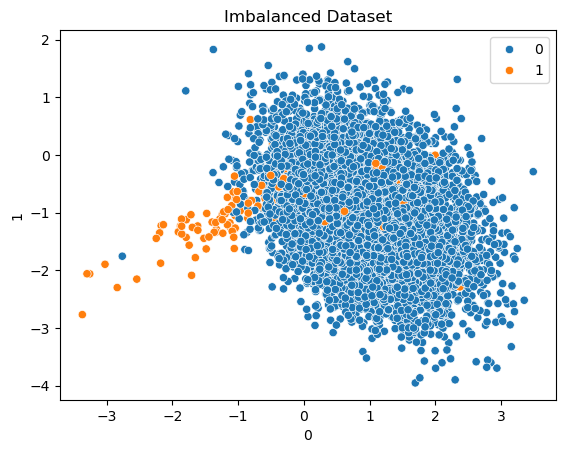

In [63]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)
plt.title('Imbalanced Dataset')


In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [65]:
from sklearn.linear_model import LogisticRegression


- Here there are lots of parameters, but there is one important parameter which is called as classweight.
- And with the help of this particular parameter you will be able to play with the imbalanced dataset.

- Classweight can either be a dictionary value or it can be balanced, if we basically say balanced, it will basically consider euqal importance for zeros and ones also. 
- And this can be use when out no. of outputs are eqaul with respect of categories.

- Since we have a imbalanced dataset we would use 'dict'.

In [66]:
model = LogisticRegression()
penalty = ['l1', 'l2', 'elesticnet']
solver = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'] 
c_values = [100, 10, 1.0, 0.1, 0.01]
class_weight = [{0:w, 1:y} for w in [1, 10, 50, 100] for y in [1, 10, 50, 100]]
params = dict(penalty=penalty, solver=solver, C=c_values, class_weight=class_weight)

In [67]:
params

{'penalty': ['l1', 'l2', 'elesticnet'],
 'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],
 'C': [100, 10, 1.0, 0.1, 0.01],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold()

In [69]:
grid = GridSearchCV(estimator = model,
                    param_grid = params,
                    scoring = 'accuracy',
                    cv = cv)

In [72]:
grid.fit(X_train, y_train)


c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: Con

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elesticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag',
                                    'saga']},
             scoring='accuracy')

In [73]:
grid.best_params_

{'C': 0.01, 'class_weight': {0: 10, 1: 50}, 'penalty': 'l2', 'solver': 'lbfgs'}

In [74]:
grid.best_score_

0.9887142857142857

In [75]:
y_pred = grid.predict(X_test)

In [76]:
# Performance Martix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

score = accuracy_score(y_test, y_pred)
print("Accuracy Score: ",score)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix: \n",cm)

print("Classification Report: \n",classification_report(y_test, y_pred))

Accuracy Score:  0.9886666666666667
Confusion Matrix: 
 [[2949    4]
 [  30   17]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      2953
           1       0.81      0.36      0.50        47

    accuracy                           0.99      3000
   macro avg       0.90      0.68      0.75      3000
weighted avg       0.99      0.99      0.99      3000

